In [2]:
!pip install mne numpy scipy matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 38.4 MB/s eta 0:00:00


Loading EEG data...
Using default location ~/mne_data for EEGBCI...
Creating /root/mne_data


Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m01s (7.4 MB)
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R10.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R14.edf...
Setting channel info structure...
Creating raw.info structure...
Re

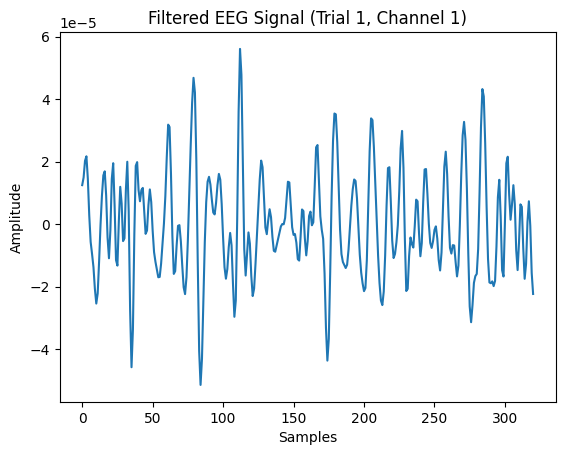

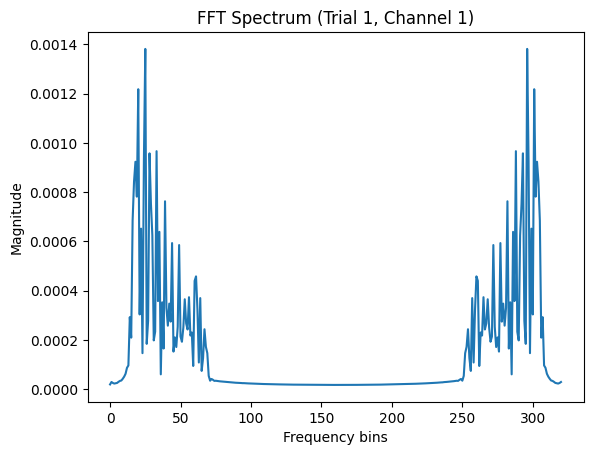

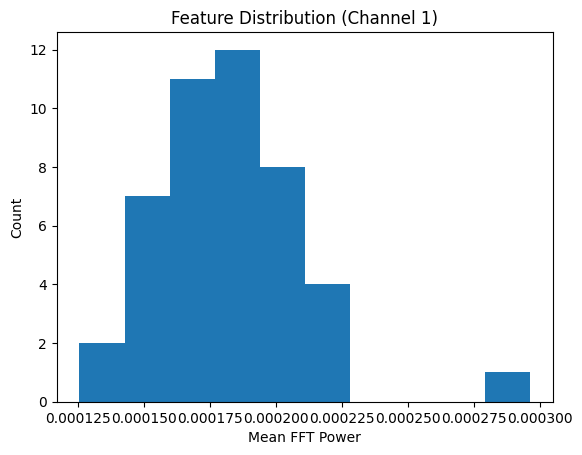


Pipeline executed successfully 🚀


In [3]:
# ==============================
# EEG Motor Imagery BCI Pipeline
# ==============================

# Install (run once if needed)
# !pip install mne numpy scipy matplotlib scikit-learn

import numpy as np
import mne
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# ==============================
# 1. LOAD DATA
# ==============================

print("Loading EEG data...")

subject = 1
runs = [6, 10, 14]

raw_files = mne.datasets.eegbci.load_data(subject, runs)
raw = mne.io.concatenate_raws([mne.io.read_raw_edf(f, preload=True) for f in raw_files])

# ==============================
# 2. PREPROCESSING
# ==============================

print("Filtering EEG (8–30 Hz)...")

raw.filter(8., 30., fir_design='firwin')

events, _ = mne.events_from_annotations(raw)

picks = mne.pick_types(raw.info, eeg=True)

epochs = mne.Epochs(
    raw,
    events,
    event_id={'left': 2, 'right': 3},
    tmin=0.,
    tmax=2.,
    picks=picks,
    baseline=None,
    preload=True
)

data = epochs.get_data()  # shape: trials x channels x samples
labels = epochs.events[:, -1]

print("Data shape:", data.shape)

# ==============================
# 3. FEATURE EXTRACTION (FFT)
# ==============================

print("Extracting FFT features...")

features = []

for trial in data:
    trial_features = []

    for channel in trial:
        fft_vals = np.abs(np.fft.fft(channel))
        mean_power = np.mean(fft_vals)
        trial_features.append(mean_power)

    features.append(trial_features)

X = np.array(features)
y = labels

print("Feature shape:", X.shape)

# ==============================
# 4. TRAIN / TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ==============================
# 5. CLASSIFICATION (KNN)
# ==============================

print("Training KNN...")

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ==============================
# 6. RESULTS
# ==============================

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n===== RESULTS =====")
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)

# ==============================
# 7. VISUALIZATION
# ==============================

# Plot EEG signal (first trial, first channel)
plt.figure()
plt.plot(data[0][0])
plt.title("Filtered EEG Signal (Trial 1, Channel 1)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

# FFT plot
fft_vals = np.abs(np.fft.fft(data[0][0]))
plt.figure()
plt.plot(fft_vals)
plt.title("FFT Spectrum (Trial 1, Channel 1)")
plt.xlabel("Frequency bins")
plt.ylabel("Magnitude")
plt.show()

# Feature histogram
plt.figure()
plt.hist(X[:, 0], bins=10)
plt.title("Feature Distribution (Channel 1)")
plt.xlabel("Mean FFT Power")
plt.ylabel("Count")
plt.show()

# ==============================
# DONE
# ==============================

print("\nPipeline executed successfully 🚀")